# **Machine Learning: Predicción de Popularidad Musical** (EA1)

> **Asignatura:** Machine Learning (MLY1101)
> 
> **Sección:** MLY1101-002D
> 
> **Institución:** Duoc UC
> 
> **Integrantes:** Abel Aravena, Benjamín Aravena, Gabriel Castillo

## Descripción del proyecto

Este proyecto corresponde al desarrollo de un modelo de **Machine Learning aplicado a un dataset de canciones de Spotify**, cuyo objetivo es analizar las características musicales de distintas canciones y utilizarlas para determinar su nivel de popularidad.

El proyecto contempla distintas etapas del ciclo de desarrollo de un modelo de Machine Learning, comenzando con el análisis exploratorio de los datos y continuando con procesos de limpieza, tratamiento de valores atípicos, ingeniería de características y preprocesamiento.

## Alcance de la experiencia

El presente notebook resumirá el trabajo realizado por el equipo durante la primera experiencia de aprendizaje, siguiendo los primeros pasos de la metodología CRISP-DM, hasta el apartado de preprocesamiento, considerando un análisis adicional sobre los aspectos éticos y legales que implica el proyecto dada su naturaleza. No se contemplan aún los pasos de implementación de modelos de Aprendizaje Automático, puesto que estos serán abordados en una próxima versión.



---

# **00. Entendiendo el negocio**

El objetivo principal es implementar un sistema de machine learning predictivo que procese características acústicas (danceability, energy, tempo, acousticness, valence, etc.) y métricas de consumo en plataformas de streaming (Spotify API) para estimar la probabilidad de éxito o popularidad de un track musical.

Este modelo generaría valor para productores musicales, cantautores, compositores y directores A&R (Artistas y Repertorio) interesados en maximizar sus ingresos dentro de la industria del entretenimiento, ofreciéndoles insumos informados para la toma de decisiones e inversión.

Los datos utilizados fueron extraídos del siguiente enlace de Kaggle en el cual se puede consultar la documentación:
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

---

# **01. Análisis Exploratorio de Datos (EDA)**

Esta fase tiene como objetivo realizar un Análisis Exploratorio de Datos (EDA, *Exploratory Data Analysis*) sobre el conjunto de datos correspondiente a pistas musicales de Spotify.

El análisis busca obtener una visión general de la estructura del dataset, evaluar su calidad, identificar características relevantes de las variables y analizar sus distribuciones mediante técnicas estadísticas y visualizaciones.

Los resultados obtenidos durante esta etapa servirán como base para las posteriores tareas de ingeniería de características, preprocesamiento y construcción de modelos de aprendizaje automático.

---

## Importación de librerías y funciones personalizadas

In [60]:
# Importación de librerías y funciones personalizadas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from category_encoders import BinaryEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import sys, os
sys.path.append(os.path.abspath(".."))

from utils.c_datos import *
from utils.det_outliers import *
from utils.est_descriptiva import *
from utils.eda_utils import *
from utils.rel_variables import *
from utils.vis_descriptiva import *

## Carga del dataset

El conjunto de datos utilizado corresponde al dataset de Spotify en su versión cruda, previo a la aplicación de las etapas de limpieza y transformación.

In [61]:
df=pd.read_csv("../dataset/spotify_crudo.csv")

El archivo se encuentra almacenado en el directorio `/dataset` del proyecto y constituye el punto de partida para el análisis exploratorio.

## Vision General del Dataset

Esta etapa tiene como finalidad obtener una primera caracterización del conjunto de datos, considerando su estructura, dimensionalidad, tipos de datos y cardinalidad de las variables.

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [63]:
df.nunique()

Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

Se obtiene la cantidad de valores únicos presentes en cada variable.

El análisis de cardinalidad resulta especialmente relevante para las variables categóricas, ya que permite identificar aquellas que poseen una gran cantidad de categorías y que, por lo tanto, podrían requerir estrategias de codificación específicas durante el preprocesamiento.

In [64]:
df['key'].unique()

array([ 1,  0,  2,  6, 11,  8,  4,  7,  3, 10,  5,  9])

Se inspeccionan explícitamente los valores únicos de la variable key, correspondiente a la tonalidad musical de las pistas.

Esta revisión permite verificar los valores presentes en la variable y detectar posibles categorías inesperadas o valores que requieran tratamiento durante la preparación de los datos.

## Evaluación de la calidad de los datos

La evaluación de calidad tiene como objetivo identificar problemas que puedan afectar las etapas posteriores de análisis y modelado.

Para mantener una estructura modular, las funciones utilizadas en esta sección se encuentran implementadas en el módulo `utils.c_datos`.

In [65]:
resultado_nulos = valores_nulos(df)
resultado_duplicados = duplicados(df)
resultado_unicos = valores_unicos(df)

Valores nulos por columna:
            nulos  porcentaje_%
artists         1      0.000877
album_name      1      0.000877
track_name      1      0.000877
Filas duplicadas: 0 (0.00%)
                  valores_unicos  porcentaje_%
Unnamed: 0                114000        100.00
track_id                   89741         78.72
track_name                 73608         64.57
duration_ms                50697         44.47
album_name                 46589         40.87
tempo                      45653         40.05
artists                    31437         27.58
loudness                   19480         17.09
instrumentalness            5346          4.69
acousticness                5061          4.44
energy                      2083          1.83
valence                     1790          1.57
liveness                    1722          1.51
speechiness                 1489          1.31
danceability                1174          1.03
track_genre                  114          0.10
popularity        

Se ejecutan tres análisis principales: 

* `valores_nulos(df)`: permite identificar la presencia de datos faltantes y determinar qué variables presentan valores ausentes.

* `duplicados(df)`: permite detectar registros repetidos dentro del conjunto de datos.

* `valores_unicos(df)`: permite analizar la cantidad y características de los valores presentes en las variables, complementando el análisis de cardinalidad realizado anteriormente.

La utilización de funciones independientes permite mantener una separación de responsabilidades y facilita la reutilización del código durante otras etapas del proyecto.

## Estadística Descriptiva

La siguiente etapa tiene como finalidad caracterizar estadísticamente las variables del dataset.

Las funciones utilizadas se encuentran implementadas en el módulo `utils.est_descriptiva`:

In [66]:
# Se calculan estadísticas diferenciadas según el tipo de variable:
display(estadisticas_numericas(df))
display(estadisticas_categoricas(df))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,rango
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000,-1.260167e-16,-1.200000,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000,4.640252e-02,-0.927755,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000,1.119518e+01,354.952416,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985,-3.994966e-01,-0.184502,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000,-5.970014e-01,-0.525711,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000,-8.500360e-03,-1.276571,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532,-2.006542e+00,5.896278,54.063
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000,-5.723005e-01,-1.672501,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965,4.647516e+00,28.824377,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996,7.272949e-01,-0.949931,0.996



--- artists ---
Moda: The Beatles
artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

--- album_name ---
Moda: Alternative Christmas 2022
album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura y Perreo              106
Esto me suena a Farra          105
Perreo en Halloween            103
Name: count, dtype: int64

--- track_name ---
Moda: Run Rudolph Run
track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Christmas Time    

None

## Visualización Descriptiva

La visualización constituye una etapa fundamental del EDA, ya que permite identificar patrones, distribuciones, posibles valores atípicos y diferencias en la frecuencia de las categorías.

Las funciones de visualización se encuentran implementadas en el módulo `utils.vis_descriptiva`:

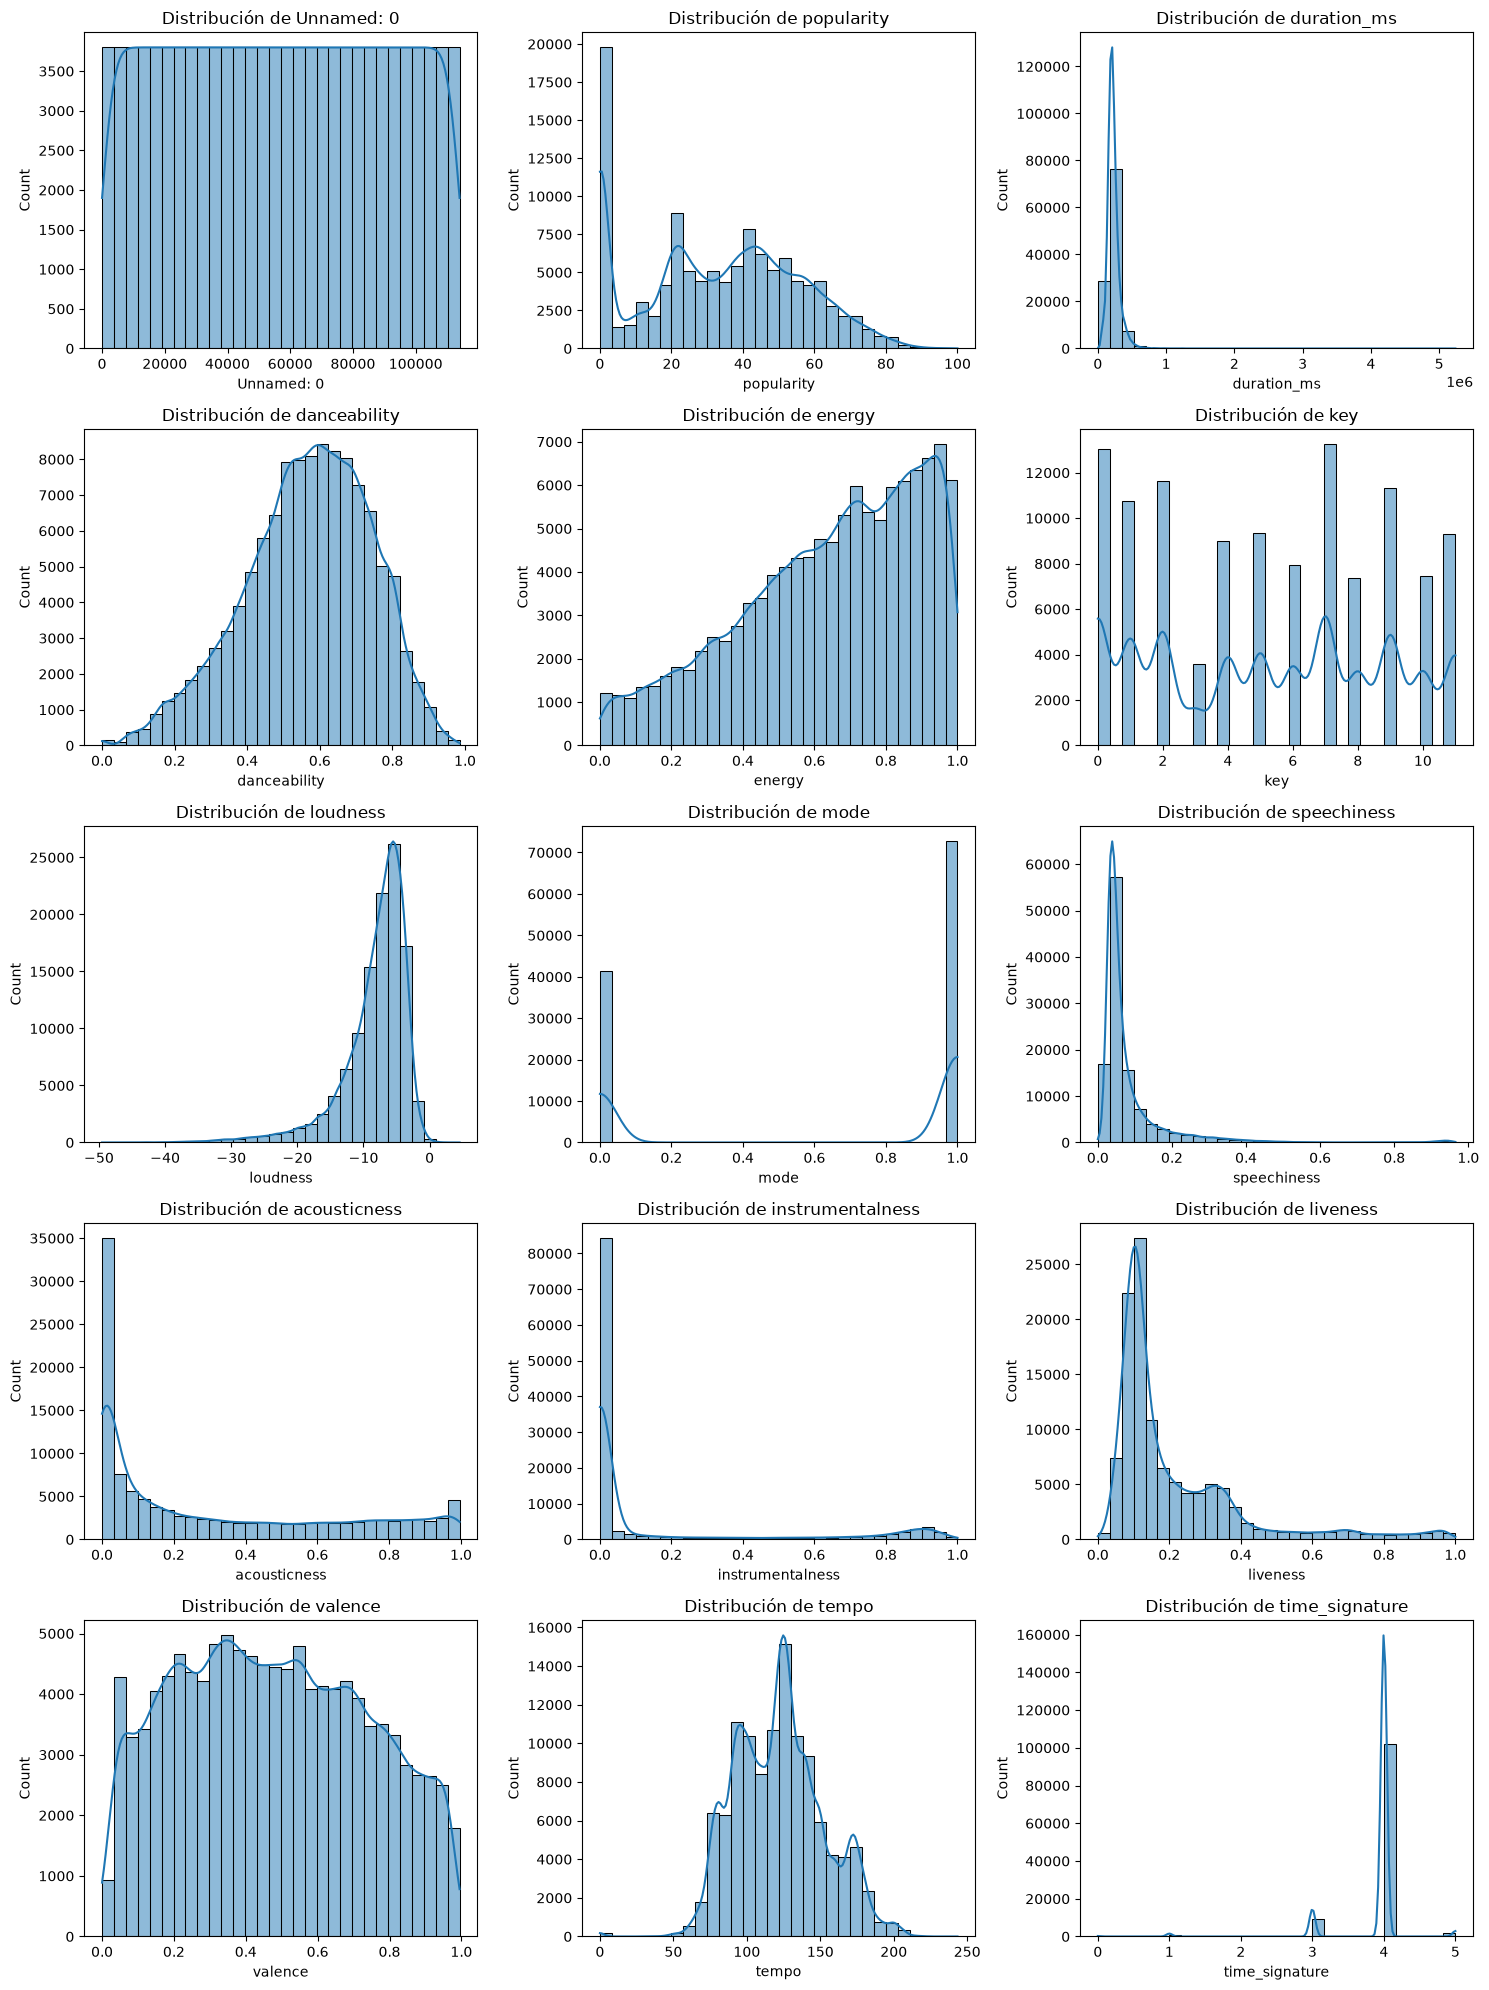

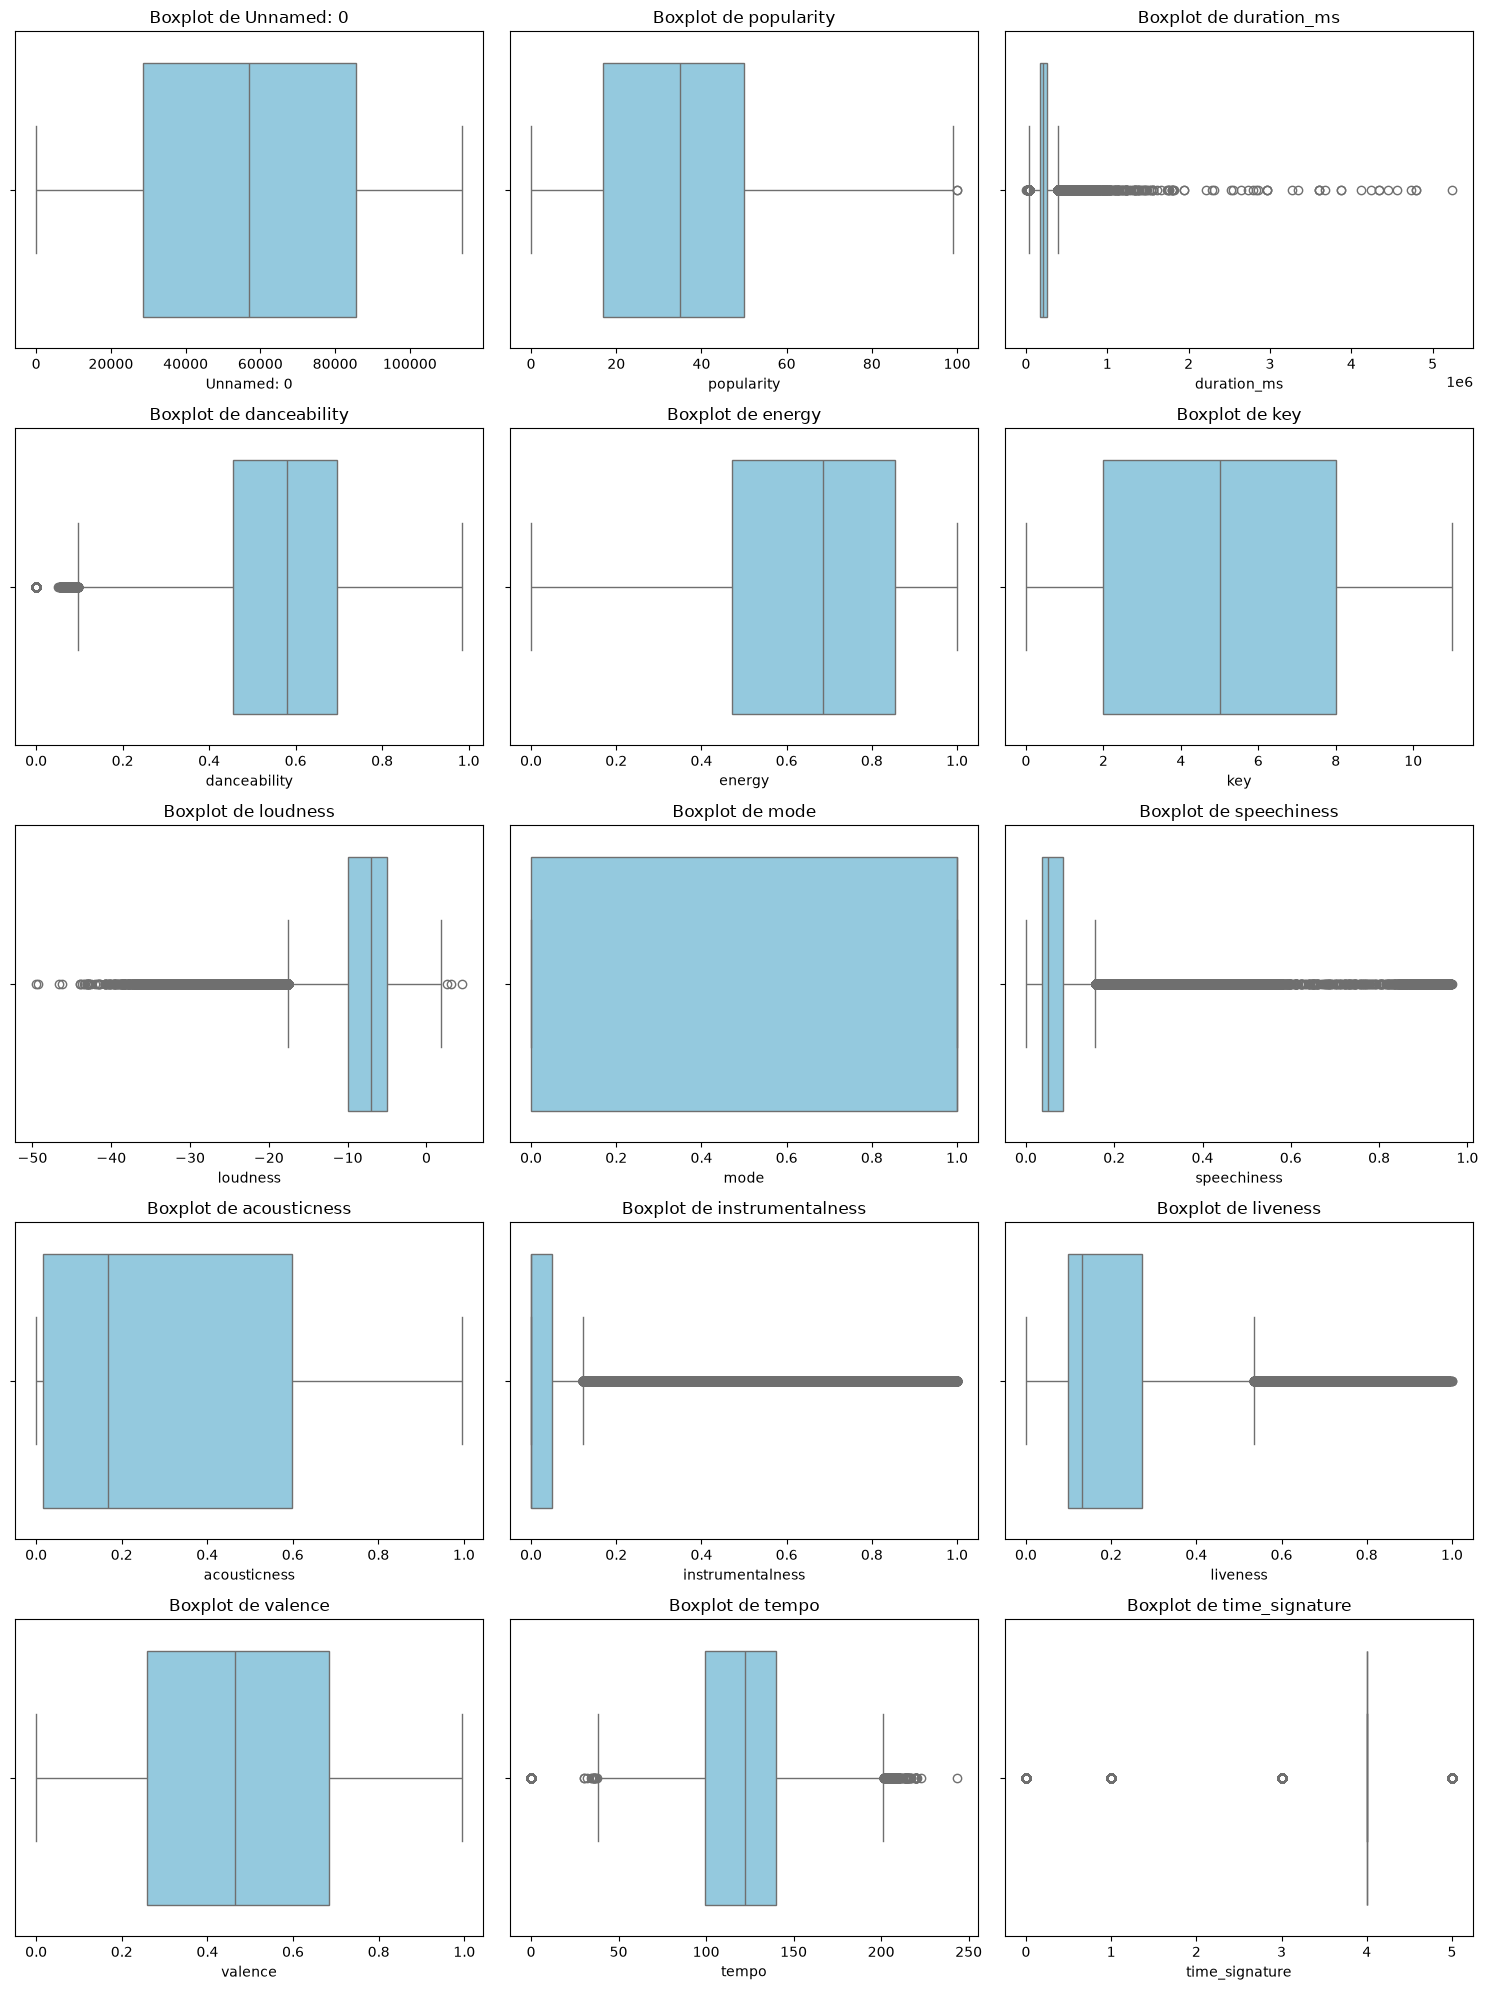

c:\Users\benja\OneDrive\Escritorio\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


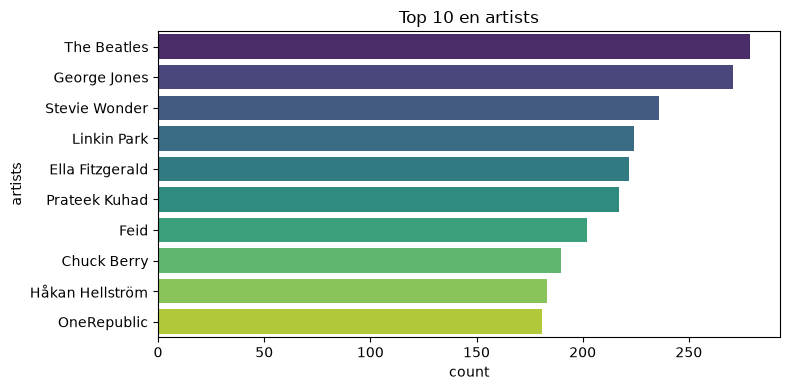

c:\Users\benja\OneDrive\Escritorio\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


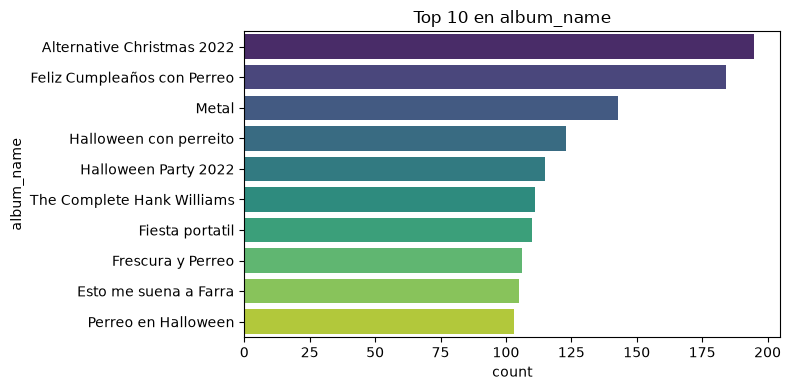

c:\Users\benja\OneDrive\Escritorio\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


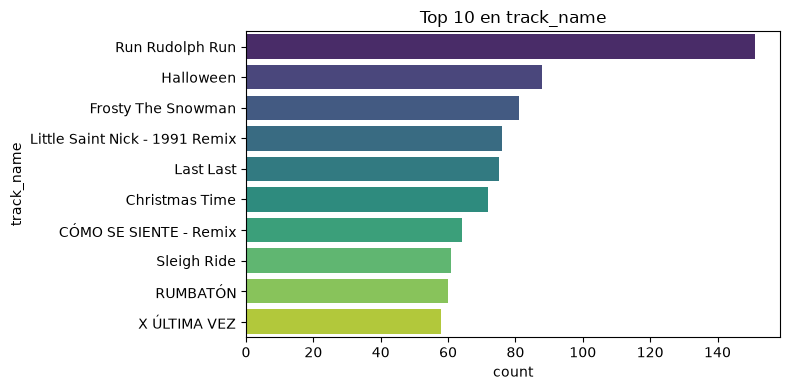

c:\Users\benja\OneDrive\Escritorio\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


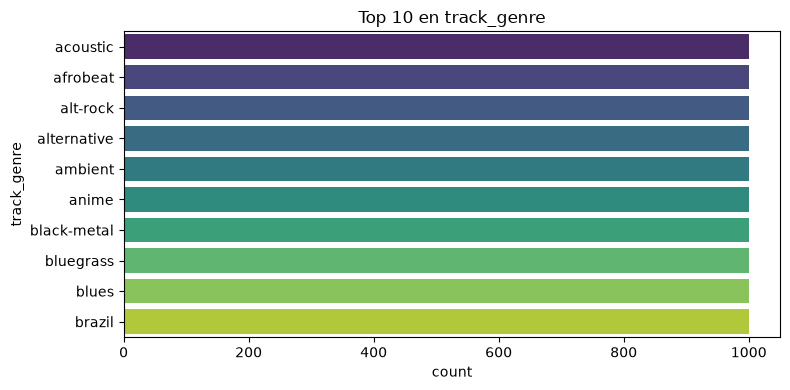

In [67]:
graficar_distribuciones_numericas(df)
graficar_boxplots(df)
graficar_categoricas(df)

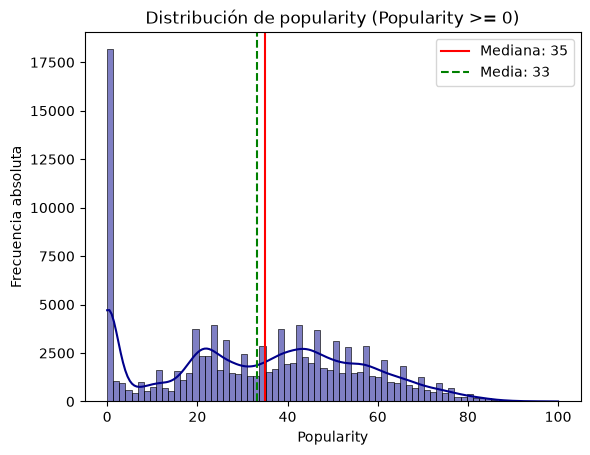

In [68]:
sns.histplot(
    data=df,
    x='popularity',
    kde=True,
    color='darkblue'
)

plt.axvline(
    df['popularity'].median(),
    label=f"Mediana: {df['popularity'].median():.0f}",
    color='red'
)

plt.axvline(
    df['popularity'].mean(),
    label=f"Media: {df['popularity'].mean():.0f}",
    color='green',
    linestyle='--'
)

plt.title('Distribución de popularity (Popularity >= 0)')
plt.xlabel('Popularity')
plt.ylabel('Frecuencia absoluta')

plt.legend()
plt.show()

In [69]:
cantidad_ceros = (df['popularity'] == 0).sum()
porcentaje_ceros = (cantidad_ceros / len(df)) * 100

print(f"Cantidad de valores 0: {cantidad_ceros}")
print(f"Porcentaje de valores 0: {porcentaje_ceros:.2f}%")

Cantidad de valores 0: 16020
Porcentaje de valores 0: 14.05%


In [70]:
df['time_signature']

0         4
1         4
2         4
3         3
4         4
         ..
113995    5
113996    4
113997    4
113998    4
113999    4
Name: time_signature, Length: 114000, dtype: int64

In [71]:
porcentaje = (df['time_signature'] == 4).mean() * 100

print(f"Porcentaje de representación de 4: {porcentaje:.2f}%")

Porcentaje de representación de 4: 89.34%


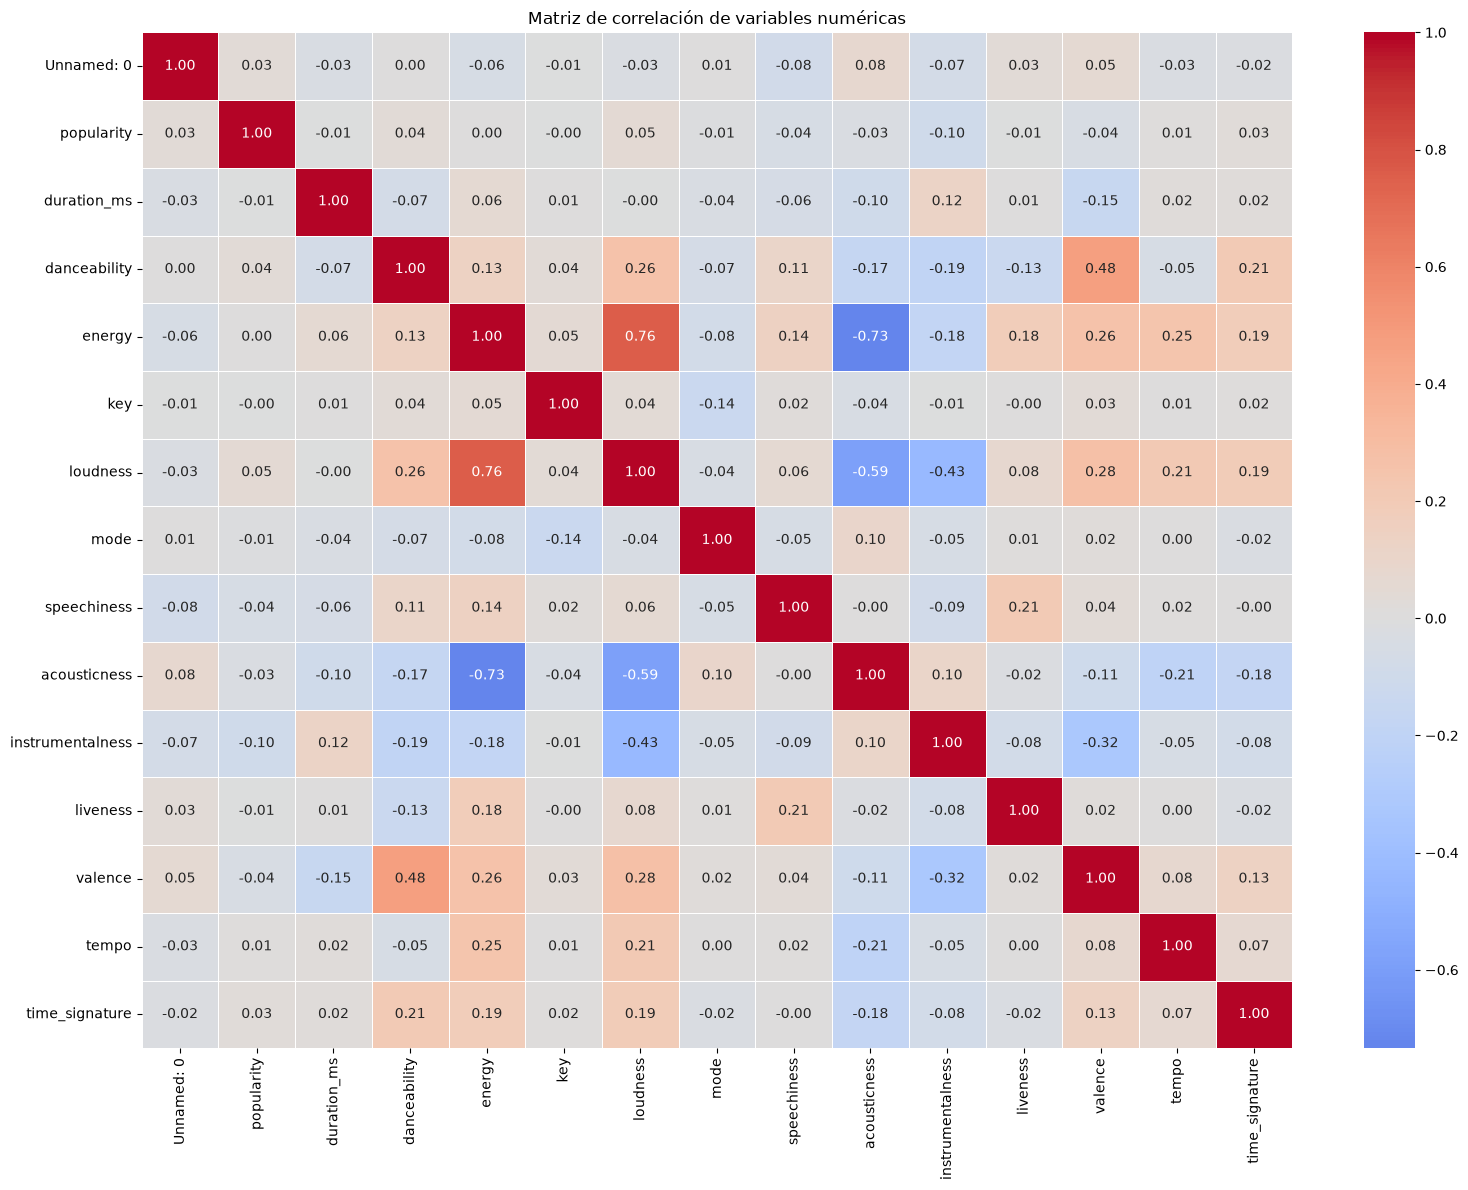

In [72]:
# Seleccionar únicamente columnas numéricas
df_numerico = df.select_dtypes(include="number")

# Calcular matriz de correlación
matriz_correlacion = df_numerico.corr()

# Visualizar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

---

# **02. Limpieza y Tratamiento de Datos**

Este apartado tiene como objetivo realizar etapas de limpieza, análisis y tratamiento de datos sobre el conjunto de datos de Spotify.

A partir del dataset crudo, se ejecutan diferentes procedimientos orientados a mejorar la calidad de los datos y preparar el conjunto de información para las etapas posteriores de ingeniería de características y modelado predictivo.

Las principales tareas realizadas son:

* Carga y preparación del dataset.

* Eliminación de variables no relevantes.
* Detección de valores atípicos (outliers).
* Comparación de métodos de detección de outliers.
* Identificación y tratamiento de valores nulos.
* Identificación y eliminación de registros duplicados.
* Análisis estadístico posterior a la limpieza.
* Aplicación de winsorización mediante el método IQR.
* Evaluación de la variable objetivo popularity.
* Visualización de las distribuciones numéricas.
* Exportación del dataset tratado.

## Inspección inicial

Antes de realizar modificaciones sobre los datos, se efectúa una inspección preliminar del conjunto de datos.

## Primeros registros

El método `head()` permite visualizar los primeros registros del dataset y obtener una primera aproximación a la estructura y contenido de las variables.

In [73]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Información estructural

La función `info()` permite identificar:

* Cantidad de registros.
* Cantidad de variables.
* Tipos de datos.
* Valores no nulos.
* Uso aproximado de memoria.

Esta información es relevante para detectar posibles inconsistencias en los tipos de datos y determinar qué variables requieren tratamiento.

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

## Eliminación de variables no relevantes

Se eliminan determinadas variables que no serán utilizadas en las etapas posteriores:

In [75]:
df = df.drop(columns=["Unnamed: 0", "track_id", "time_signature"])

Las variables eliminadas corresponden a:

`Unnamed: 0`

Corresponde a una columna de índice generada durante la manipulación o exportación previa del dataset. No representa una característica musical relevante y, por lo tanto, se elimina.

`track_id`

Corresponde a un identificador único de la pista. Debido a que funciona principalmente como identificador y no como una característica predictiva con significado numérico directo, se excluye del conjunto de variables utilizadas para el análisis.

`time_signature`

Esta variable representa la métrica o compás de la canción. En este proceso se decidió eliminar puesto que en la gran mayoría de sus aparciones (aproximadamente 90%) esta se mantiene con un valor "4" constante, su baja variabilidad solo causaría ruido.

## Detección de valores atípicos

Una parte importante del proceso de limpieza corresponde a la identificación de valores atípicos (outliers).

Para esto se utiliza la estrategias implementada en `eda_utils`:

In [76]:
outliers_iqr = detectar_outliers_iqr(df)

Se considera el método:

* Método del rango intercuartílico (IQR).

Puesto que en la fase de análisis exploratorio se logró identificar que las variables de este caso no siguen una distribución normal, por lo qué IQR es más robusta para medir outliers.

In [77]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")

total_outliers_iqr = 0

outliers_iqr = detectar_outliers_iqr(df)
for col, info in outliers_iqr.items():
    total_outliers_iqr += info["cantidad_outliers"]

    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

print(f"TOTAL DE OUTLIERS IDENTIFICADOS: {total_outliers_iqr}")

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.046
Cantidad de outliers: 2
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 11.195
Cantidad de outliers: 5617
Límite inferior: 42906.000
Límite superior: 392666.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.399
Cantidad de outliers: 620
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.597
Cantidad de outliers: 0
Límite inferior: -0.101
Límite superior: 1.427
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -2.007
Cantidad de outliers: 6173
Límite inferior: -17.528
Límite superior: 2.512
-------

## Tratamiento de valores nulos

Se verifica la cantidad de valores ausentes mediante:

In [78]:
df.isna().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64

Se identificaron 3 registros con valores nulos en un dataset compuesto por un total de 114.000 registros. Lo que equivale a solo un 0,003%.

Dado esto, se optó por la eliminación de los registros con valores nulos, al no suponer una pérdida significativa para el modelo.

In [79]:
df = df.dropna()

## Identificación y tratamiento de duplicados

Se determina inicialmente la cantidad de registros duplicados:

In [81]:
duplicados = df[df.duplicated(keep=False)]

In [115]:
print(f"Duplicados encontrados: {len(duplicados)}")

Duplicados encontrados: 1129


El parámetro `keep=False` permite identificar todas las apariciones de un registro duplicado, en lugar de marcar únicamente las ocurrencias posteriores a la primera.

In [82]:
duplicados

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
1874,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,afrobeat
1925,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,afrobeat
2044,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.060100,0.000000,0.3070,0.662,120.041,alt-rock
2046,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.060100,0.000000,0.3070,0.662,120.041,alt-rock
2082,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.165,0.434,0,-8.163,1,0.0288,0.316000,0.171000,0.2130,0.186,77.983,alt-rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112968,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,turkish
113295,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,world-music
113345,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,world-music
113881,Bryan & Katie Torwalt,I've Got Good News (Live) [Deluxe],Good News - Live,23,266632,False,0.473,0.474,6,-9.175,1,0.0558,0.395000,0.000000,0.1630,0.251,140.746,world-music


In [83]:
df = df.drop_duplicates()

Este procedimiento permite evitar que observaciones repetidas tengan una influencia desproporcionada sobre las estadísticas descriptivas y los modelos posteriores.

## Visualización de outliers

Después del tratamiento de valores nulos y duplicados, se vuelve a ejecutar la detección de outliers.

Posteriormente, se genera una representación gráfica de la cantidad de outliers detectados por variable:

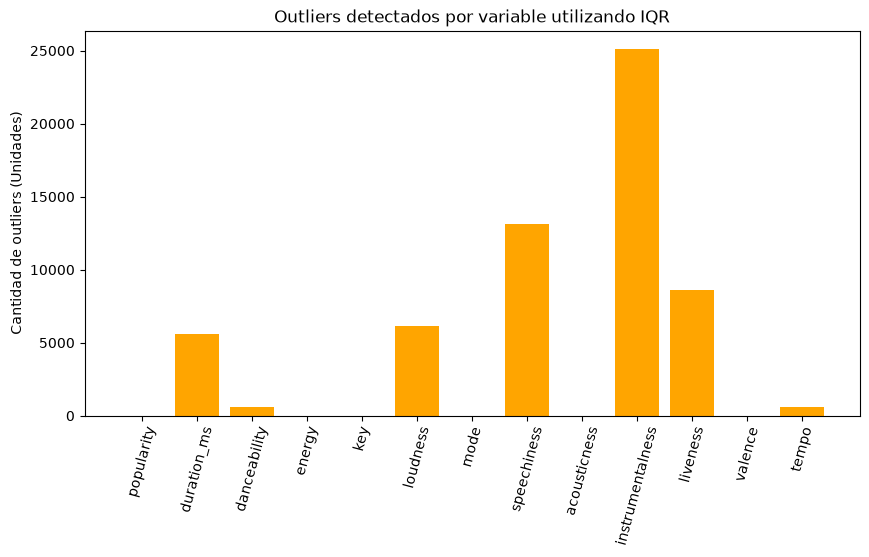

In [84]:
resultados = detectar_outliers_iqr(df)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()

Esta visualización permite comparar rápidamente la cantidad de observaciones atípicas presentes en cada variable numérica.

La representación facilita la identificación de variables que requieren una atención especial durante el tratamiento de valores extremos.

In [85]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113422.000000,1.134220e+05,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000
mean,33.359674,2.281011e+05,0.567113,0.642174,5.309332,-8.242913,0.637681,0.084697,0.314075,0.155802,0.213610,0.474239,122.176181
std,22.269626,1.064508e+05,0.173402,0.251031,3.559767,5.011931,0.480673,0.105803,0.331943,0.309314,0.190481,0.259239,29.972104
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741700e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.299000
50%,35.000000,2.130160e+05,0.580000,0.685000,5.000000,-6.996000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.019000
75%,50.000000,2.616000e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084575,0.596000,0.048700,0.273000,0.683000,140.073000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


# Winsorización de valores atípicos

Para tratar los valores extremos restantes se aplica winsorización mediante el método IQR:

$$IQR = Q3 - Q1$$

La winsorización consiste en limitar los valores extremos, reemplazándolos por los valores correspondientes a los límites establecidos.

A diferencia de eliminar observaciones, esta estrategia conserva la cantidad de registros del dataset y reduce la influencia de valores extremos.
Lo cual es útil dado que estos mismos no corresponden necesariamente a errores de medición, sino que representan observaciones reales presentes en el dataset.

En términos conceptuales:
<div align="center">

**Valor inferior extremo**  
↓  
**Límite inferior IQR**

<br>

**Valor superior extremo**  
↓  
**Límite superior IQR**

</div>
De esta manera, las observaciones no son eliminadas, sino que sus valores son restringidos al rango considerado aceptable según el criterio utilizado.

In [86]:
df_wins = winsorizar_iqr(df)

df_wins.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000
mean,33.359666,222615.009601,0.567327,0.642174,5.309332,-7.928039,0.637681,0.067221,0.314075,0.030741,0.196611,0.474239,122.210463
std,22.269600,73091.061378,0.172775,0.251031,3.559767,3.997161,0.480673,0.042555,0.331943,0.050686,0.140762,0.259239,29.735829
min,0.000000,43025.000000,0.097500,0.000000,0.000000,-17.493500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,38.138000
25%,17.000000,174170.000000,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.299000
50%,35.000000,213016.000000,0.580000,0.685000,5.000000,-6.996000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.019000
75%,50.000000,261600.000000,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084575,0.596000,0.048700,0.273000,0.683000,140.073000
max,99.500000,392745.000000,0.985000,1.000000,11.000000,2.494500,1.000000,0.157587,0.996000,0.121750,0.535500,0.995000,201.234000


In [87]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")

total_outliers_iqr = 0

outliers_iqr = detectar_outliers_iqr(df_wins)
for col, info in outliers_iqr.items():
    total_outliers_iqr += info["cantidad_outliers"]

    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

print(f"TOTAL DE OUTLIERS IDENTIFICADOS: {total_outliers_iqr}")

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.041
Cantidad de outliers: 0
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 0.499
Cantidad de outliers: 0
Límite inferior: 43025.000
Límite superior: 392745.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.377
Cantidad de outliers: 0
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.599
Cantidad de outliers: 0
Límite inferior: -0.099
Límite superior: 1.425
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -0.869
Cantidad de outliers: 0
Límite inferior: -17.493
Límite superior: 2.494
----------------

## Evaluación de los valores atípicos después de la winsorización

Después de aplicar la winsorización, se vuelve a ejecutar la detección de outliers mediante IQR:

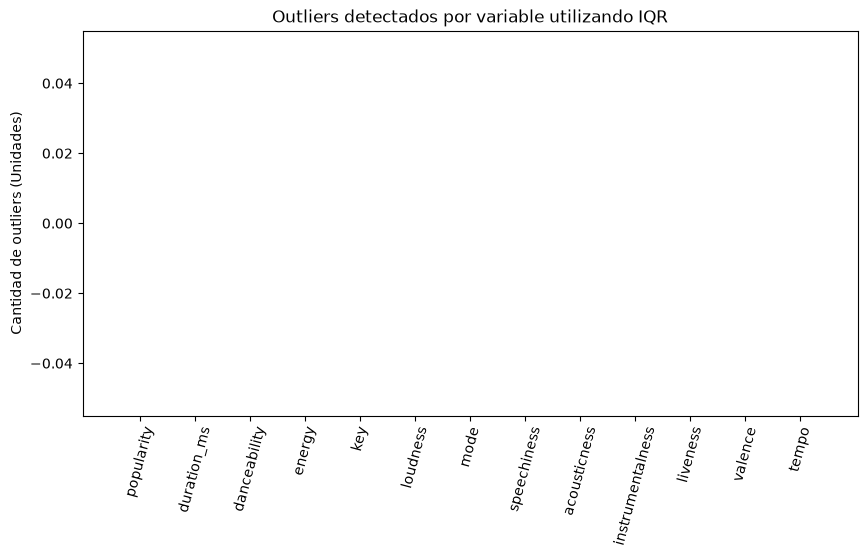

In [88]:
resultados = detectar_outliers_iqr(df_wins)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()



Esto permite comprobar el efecto producido por el tratamiento.

## Análisis de la variable objetivo `popularity`

Una vez realizado el tratamiento de los datos, se analiza la distribución de la variable `popularity`.

Para ello, se utiliza un histograma acompañado de una estimación de densidad:

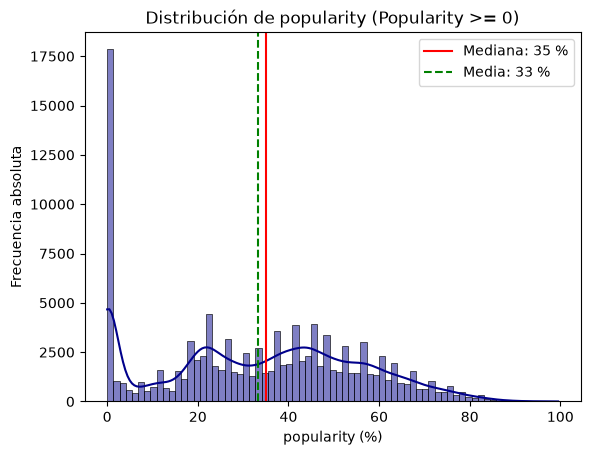

In [89]:
sns.histplot(
    data = df_wins,
    x = 'popularity',
    kde = True,
    color="darkblue"
)

plt.axvline(df_wins['popularity'].median(), label = f'Mediana: {df_wins['popularity'].median():.0f} %', color = 'red')
plt.axvline(df_wins['popularity'].mean(), label = f'Media: {df_wins['popularity'].mean():.0f} %', color = 'green', linestyle = '--')
plt.title('Distribución de popularity (Popularity >= 0)')
plt.xlabel('popularity (%)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.show()

## Análisis de `popularity` excluyendo valores iguales a cero

Posteriormente, se realiza un segundo análisis excluyendo las canciones cuya popularidad es igual a cero.

Esta separación permite analizar la distribución de popularidad de las canciones que presentan un valor positivo, evitando que una gran concentración de observaciones con `popularity = 0` pueda dificultar la interpretación de la distribución.

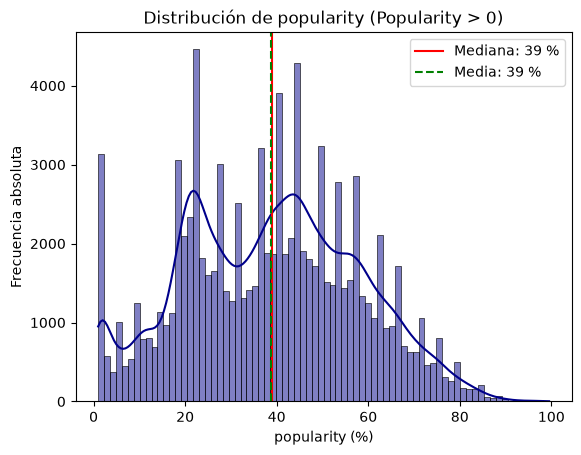

In [90]:
df_filtered = df_wins[df_wins['popularity'] > 0]

sns.histplot(
    data=df_filtered,
    x='popularity',
    kde=True,
    color="darkblue"
)

mediana = df_filtered['popularity'].median()
media = df_filtered['popularity'].mean()


plt.axvline(mediana, label=f"Mediana: {mediana:.0f} %", color='red')
plt.axvline(media, label=f"Media: {media:.0f} %", color='green', linestyle='--')

plt.title('Distribución de popularity (Popularity > 0)')
plt.xlabel('popularity (%)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.show()

## Visualización general de las distribuciones numéricas

Para complementar el análisis individual de popularity, se generan gráficos de distribución para las variables numéricas del dataset:

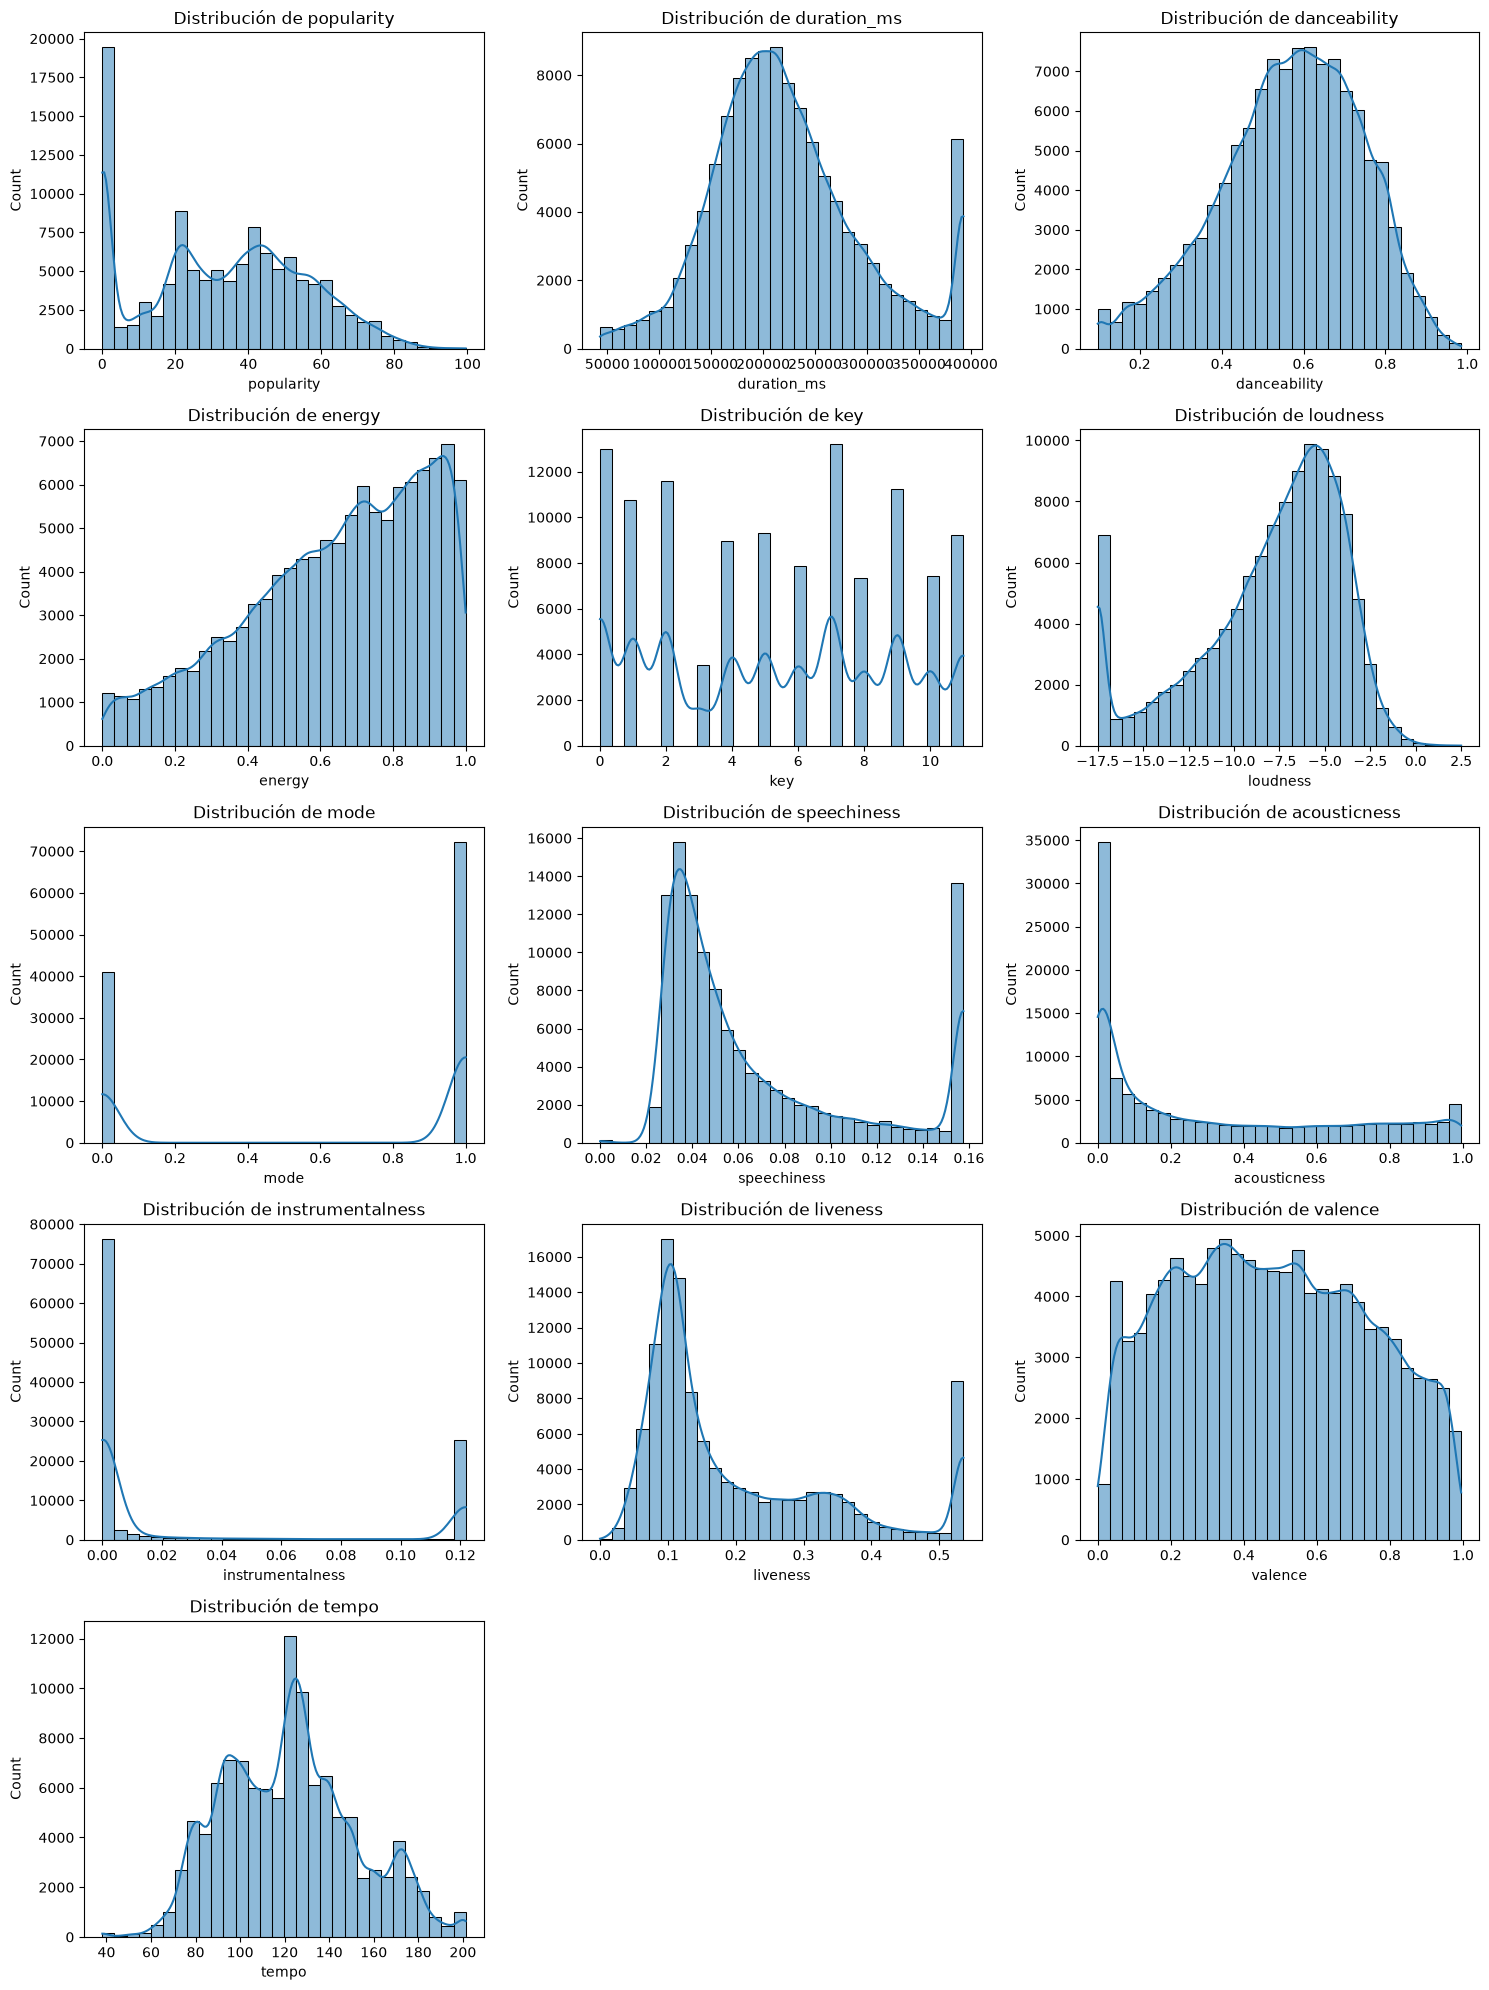

In [91]:
graficar_distribuciones_numericas(df_wins)

## Exportación del dataset tratado

Una vez finalizado el proceso de limpieza y tratamiento de valores extremos, el dataset resultante se exporta en formato CSV:

In [92]:
df_wins.to_csv("../dataset/spotify_winsorizado.csv", index=False)

# **03. Ingeniería de características**

El objetivo es realizar la ingeniería de características sobre el dataset previamente limpiado y winsorizado.

En esta etapa se realizan principalmente las siguientes transformaciones:

* Carga del dataset `spotify_winsorizado.csv`.
* Conversión de la duración de las canciones desde milisegundos a minutos.
* Creación de una variable categórica para representar la duración de las canciones.
* Evaluación exploratoria de una alternativa basada en cuantiles.
* Eliminación de la variable original `duration_ms`.
* Transformación de popularity en una variable categórica ordinal denominada popularity_category.
* Exportación del dataset resultante como `spotify_engineering.csv`.

Esta etapa prepara los datos para el posterior preprocesamiento y modelamiento mediante Machine Learning.

## Tipos de variables

El dataset contiene diferentes tipos de variables que pueden clasificarse conceptualmente según su función dentro del análisis.

Identificación/texto: 
* *`artists`*
* *`album_name`*
* *`track_name`*
* *`track_genre`*

Estas variables contienen información textual relacionada con la canción, artista, álbum y género musical.

Debido a su naturaleza categórica y a su elevada cardinalidad, posteriormente requerirán técnicas específicas de codificación para poder ser utilizadas por los modelos de Machine Learning.

Variable objetivo: 
* *`popularity`*

Esta variable será posteriormente transformada en categorías ordinales para definir el objetivo del modelo predictivo.

Audio: 
* *`danceability`*,
* *`energy`*
* *`loudness`*
*  *`speechiness`*
* *`acousticness`*
* *`instrumentalness`* 
* *`liveness`*
* *`valence`*
* *`tempo`*

Estas variables representan diferentes características acústicas de las canciones.

Otras: 
* *`duration_ms`*
* *`explicit`*
* *`key`*
* *`mode`*

Estas variables contienen información adicional sobre cada canción.


## Carga del dataset winsorizado

In [93]:
data = pd.read_csv("../dataset/spotify_winsorizado.csv")

df = data.copy()

## Inspección de `duration_ms`

Se inspecciona inicialmente la variable:

In [94]:
df['duration_ms']

0         230666
1         149610
2         210826
3         201933
4         198853
           ...  
113417    384999
113418    385000
113419    271466
113420    283893
113421    241826
Name: duration_ms, Length: 113422, dtype: int64

La variable `duration_ms` representa la duración de cada canción en milisegundos.

Aunque esta unidad resulta adecuada para almacenar valores numéricos con precisión, no es especialmente intuitiva para realizar análisis exploratorios.

Por este motivo, se genera una nueva representación de la duración expresada en minutos.

## Conversión de duración de milisegundos a minutos

Se crea la nueva variable `duration_min`:

In [95]:
df["duration_min"] = df["duration_ms"] / 60000

df['duration_min']

0         3.844433
1         2.493500
2         3.513767
3         3.365550
4         3.314217
            ...   
113417    6.416650
113418    6.416667
113419    4.524433
113420    4.731550
113421    4.030433
Name: duration_min, Length: 113422, dtype: float64

## Ventaja de la transformación

Trabajar con minutos facilita:

* La interpretación de los valores.
* El análisis estadístico.
* La generación de visualizaciones.
* La construcción posterior de categorías de duración.

## Determinación de bins mediante Sturges

In [96]:
# Esta variable se utilizará solo para fines exploratorios
# No se incluirá en el modelo de ML

df['duration_category'] = pd.cut(
    df["duration_min"],
    bins=[0, 2.5, 4, 6, float("inf")],
    labels=["Corta", "Media", "Larga", "Muy larga"]
)

df.describe(include='category')

,duration_category
count,113422
unique,4
top,Media
freq,59307


## Eliminación columna `duration_ms`

Al haber creado la columna `duration_min` es redundante tener la columna `duration_ms` por lo que se eliminirá del dataset.

In [98]:
df.drop(columns=["duration_ms"], inplace=True)

## Creación de la variable ordinal `popularity_category`

In [99]:
df["popularity_category"] = pd.cut(
    df["popularity"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"],
    include_lowest=True
)

## Exportación del dataset tratado

Una vez finalizado el proceso de ingeniería de datos, el dataset resultante se exporta en formato CSV:

In [100]:
df.to_csv("../dataset/spotify_engineering.csv", index=False)

---

# **04. Preprocesamiento y Preparación**

Como última parte de esta experiencia, se realizará el preprocesamiento de los datos obtenidos durante la etapa de ingeniería de características, dejando los conjuntos de datos preparados para su utilización en modelos de Machine Learning.

En esta etapa se realizan principalmente las siguientes operaciones:

* Carga del dataset `spotify_engineering.csv.`
* Identificación de variables categóricas.
* Análisis de cardinalidad.
* Visualización de la cantidad de categorías por variable.
* Identificación y definición de variables ordinales.
* Definición de variables categóricas de alta cardinalidad.
* Definición de variables numéricas.
* Codificación mediante `BinaryEncoder`.
* Codificación ordinal mediante `OrdinalEncoder`.
* Estandarización mediante `StandardScaler`.
* Construcción de un `ColumnTransformer`.
* Separación entre variables predictoras (X) y variable objetivo (y).
* Conversión de popularity_category a valores numéricos.
* División estratificada en conjuntos de entrenamiento y prueba.
* Ajuste del pipeline únicamente sobre el conjunto de entrenamiento.
* Transformación de los conjuntos de entrenamiento y prueba.
* Reconstrucción de los DataFrames preprocesados.
* Exportación de los conjuntos finales.

El resultado de esta etapa corresponde a dos archivos:

* `Spotify_train_preprocesado.csv`
* `Spotify_test_preprocesado.csv`

Estos archivos contienen los datos transformados y preparados para el entrenamiento y evaluación de los modelos predictivos.

## Carga del dataset ajustado

Se carga el dataset obtenido después de la etapa de ingeniería de características:

In [101]:
data = pd.read_csv("../dataset/spotify_engineering.csv")

df = data.copy()

df.head()

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,duration_min,duration_category,popularity_category
0,Gen Hoshino,Comedy,Comedy,73.0,False,0.676,0.4610,1,-6.7460,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic,3.844433,Media,Alta
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,False,0.420,0.1660,1,-17.2350,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic,2.493500,Corta,Media
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,False,0.438,0.3590,0,-9.7340,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic,3.513767,Media,Media
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,False,0.266,0.0596,0,-17.4935,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic,3.365550,Media,Alta
4,Chord Overstreet,Hold On,Hold On,82.0,False,0.618,0.4430,2,-9.6810,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic,3.314217,Media,Muy alta


## Identificación de variables categóricas

In [102]:
# Obtener columnas categóricas
columnas_categoricas = df.select_dtypes(
    include=["object", "category", "str"]
).columns

print("Variables categóricas encontradas:")
print(columnas_categoricas)

Variables categóricas encontradas:
Index(['artists', 'album_name', 'track_name', 'track_genre',
       'duration_category', 'popularity_category'],
      dtype='str')


Esta identificación es necesaria porque las variables categóricas no pueden ser utilizadas directamente por la mayoría de los modelos de Machine Learning.

Por esta razón, posteriormente deben transformarse mediante técnicas de codificación.

## Análisis de cardinalidad

Una vez identificadas las variables categóricas, se calcula su cardinalidad:

In [103]:
cardinalidad = pd.DataFrame({
    "Variable": columnas_categoricas,
    "Cantidad de categorías": [
        df[col].nunique()
        for col in columnas_categoricas
    ]
})

cardinalidad.sort_values(
    by="Cantidad de categorías",
    ascending=False
)

,Variable,Cantidad de categorías
2,track_name,73608
1,album_name,46589
0,artists,31437
3,track_genre,114
5,popularity_category,5
4,duration_category,4


## Visualización de la cardinalidad

La cardinalidad se representa gráficamente mediante un gráfico de barras:

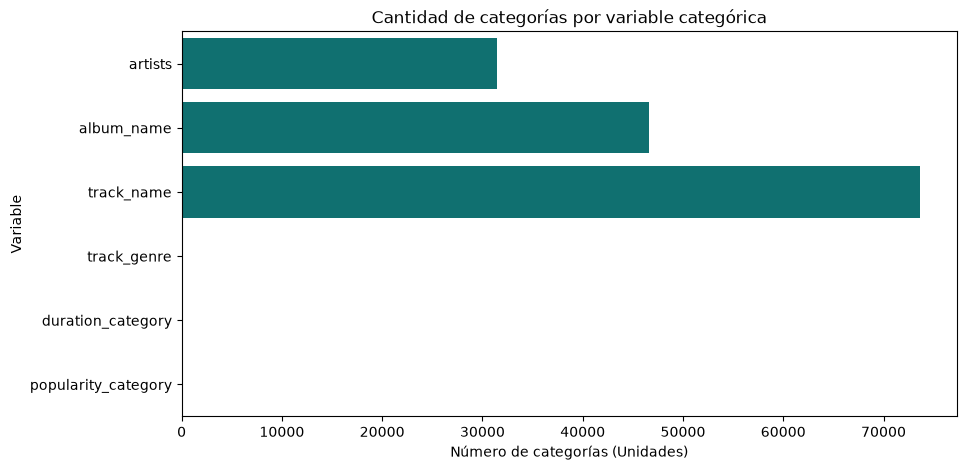

In [104]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cardinalidad,
    x="Cantidad de categorías",
    y="Variable",
    color="teal"
)

plt.title(
    "Cantidad de categorías por variable categórica"
)

plt.xlabel("Número de categorías (Unidades)")
plt.ylabel("Variable")

plt.show()

Esta visualización permite comparar fácilmente la cantidad de categorías existentes en cada variable.

El análisis es especialmente útil para justificar la selección de BinaryEncoder para las variables categóricas con mayor cardinalidad.

## Definición del orden de las variables

In [105]:
# Definición explícita del orden de las variables ordinales.
# Este orden será utilizado por OrdinalEncoder para asignar
# valores numéricos respetando la jerarquía natural de cada categoría.

categories_ordinal = [

    # Duración de la canción: Corta -> Muy larga
    [
        'Corta',
        'Media',
        'Larga',
        'Muy larga'

    ]
]

# Variables categóricas ordinales
# Estas variables poseen un orden natural entre sus categorías,
# por lo que serán codificadas mediante OrdinalEncoder
# utilizando el orden definido en 'categories_ordinal'.

cols_ordinal = [
    'duration_category'
]


# Variables categóricas de alta cardinalidad.
# Se utilizará BinaryEncoder para reducir la cantidad de columnas
# generadas en comparación con OneHotEncoder, manteniendo gran parte
# de la información de las categorías y disminuyendo la dimensionalidad
# del conjunto de datos.

cols_binary = [
    'track_genre'
]

cols_numeric = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_min'
]

## Construcción del pipeline ordinal

Para la variable ordinal se crea un pipeline independiente:

In [106]:
ordinal_pipeline = Pipeline([
    (
        'ordinal',
        OrdinalEncoder(
            categories=categories_ordinal
        )
    ),
    (
        'scaler',
        StandardScaler()
    )
])

Esta decisión permite mantener el orden ordinal y, al mismo tiempo, aplicar una escala comparable con las variables numéricas.

## Construcción del `ColumnTransformer`

El preprocesamiento completo se integra mediante:

In [107]:
pipeline = ColumnTransformer(
    transformers=[
        (
            'bin',
            BinaryEncoder(),
            cols_binary
        ),
        (
            'ord',
            ordinal_pipeline,
            cols_ordinal
        ),
        (
            'num',
            StandardScaler(),
            cols_numeric
        )
    ],
    remainder='drop'
)

El `ColumnTransformer` permite aplicar diferentes transformaciones de manera independiente, dependiendo del tipo de variable.

En este caso, las variables del dataset se distribuyen en tres grupos principales: 
categóricas de alta cardinalidad, ordinales y numéricas. Cada grupo recibe la transformación correspondiente antes de combinarse nuevamente en un único dataset transformado.

### Uso de `remainder='drop'` en el pipeline

El parámetro:

`remainder='drop'`

indica que cualquier columna que no haya sido incluida explícitamente en alguno de los grupos definidos será descartada por el `ColumnTransformer`.

Esto permite controlar exactamente qué variables ingresarán al conjunto final de características.

En este proyecto, esta decisión resulta particularmente importante porque:

`popularity`

y:

`popularity_category`

no deben formar parte de las variables predictoras.

## Separación entre variables predictoras y objetivo

Se construye el conjunto de variables predictoras `X`:

In [108]:
X = df.drop(
    columns=[
        'popularity',
        'popularity_category'
    ]
)

# La variable objetivo inicialmente se obtiene mediante:
y = df['popularity_category']

Se eliminan ambas variables porque:

`popularity`: corresponde a la variable original a partir de la cual se construyó el objetivo.

`popularity_category`: corresponde directamente a la variable objetivo.

## Transformación de `popularity_category` a valores numéricos

Para representar las categorías de popularidad mediante valores numéricos se define un mapeo explícito:

In [109]:
mapeo_popularidad = {
    'Muy baja': 0,
    'Baja': 1,
    'Media': 2,
    'Alta': 3,
    'Muy alta': 4
}

y = df['popularity_category'].map(mapeo_popularidad)

Esta transformación permite representar la variable objetivo de forma numérica para los modelos de clasificación.

Es importante diferenciar esta transformación del `OrdinalEncoder` utilizado para las variables predictoras.

En este caso, `popularity_category` corresponde al target, por lo que se realiza un mapeo explícito en lugar de incluirla dentro del `ColumnTransformer`.

## Separación Train/Test

Los datos se dividen utilizando:

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Se utiliza una proporción de:

80 % → entrenamiento

20 % → prueba

## Uso de `random_state=42` en `Train_test_split`

El parámetro:

`random_state=42`

permite obtener una división reproducible.

Esto significa que al ejecutar nuevamente el código bajo las mismas condiciones, se obtiene la misma separación entre entrenamiento y prueba.

Esto facilita:

* Reproducibilidad.
* Comparación de modelos.
* Depuración.
* Documentación del experimento.

## Uso de `stratify=y` en `Train_test_split`

para mantener aproximadamente la misma distribución de las cinco categorías de popularidad tanto en entrenamiento como en prueba.

Esto es especialmente importante porque el problema corresponde a una clasificación multiclase con cinco categorías:

0 → Muy baja

1 → Baja

2 → Media

3 → Alta

4 → Muy alta

## Ajuste y transformación del pipeline

Una vez realizada la división, se ajusta el pipeline únicamente utilizando el conjunto de entrenamiento:

In [111]:
X_train_transformado = pipeline.fit_transform(X_train)

X_test_transformado = pipeline.transform(X_test)

# Obtención del nombre de las variables transformadas
columnas_transformadas = pipeline.get_feature_names_out()

# Reconstrucción del dataset de entrenamiento
df_train_preprocesado = pd.DataFrame(
    X_train_transformado,
    columns=columnas_transformadas,
    index=X_train.index
)

# Reconstrucción del dataset de pruebas
df_test_preprocesado = pd.DataFrame(
    X_test_transformado,
    columns=columnas_transformadas,
    index=X_test.index
)

# Incorporación de la variable objetivo
df_train_preprocesado['popularity_category'] = y_train
df_test_preprocesado['popularity_category'] = y_test

El método `fit_transform()` realiza dos operaciones:

* Calcula los parámetros necesarios utilizando `X_train`.

* Aplica las transformaciones a `X_train`.

Por ejemplo, `StandardScaler` calcula la media y desviación estándar utilizando exclusivamente los datos de entrenamiento.

## Transformación del conjunto de prueba

Para el conjunto de prueba se utiliza:

`X_test_transformado = pipeline.transform(X_test)`

En este caso se utiliza únicamente `transform()`.

Esto es fundamental para evitar **data leakage**.

El pipeline no vuelve a calcular sus parámetros utilizando `X_test`.

Esta separación garantiza que la información estadística del conjunto de prueba no influya en el procesamiento del conjunto de entrenamiento.

## Inspección de los datos preprocesados

In [112]:
df_train_preprocesado.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
7631,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
11659,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
40000,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
19925,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
93716,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


In [113]:
df_test_preprocesado.head()

,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
4064,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
67107,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
66713,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
18154,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
25733,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


## Exportación de los conjuntos preprocesados

Finalmente, se exportan ambos conjuntos a archivos CSV.

In [114]:
# Exportar conjuntos preprocesados
df_train_preprocesado.to_csv(
    "../dataset/Spotify_train_preprocesado.csv",
    index=False
)

df_test_preprocesado.to_csv(
    "../dataset/Spotify_test_preprocesado.csv",
    index=False
)

El dataset contiene diferentes tipos de variables que pueden clasificarse conceptualmente según su función dentro del análisis.

Identificación/texto: 
* *`artists`*
* *`album_name`*
* *`track_name`*
* *`track_genre`*

Estas variables contienen información textual relacionada con la canción, artista, álbum y género musical.

Debido a su naturaleza categórica y a su elevada cardinalidad, posteriormente requerirán técnicas específicas de codificación para poder ser utilizadas por los modelos de Machine Learning.

Variable objetivo: 
* *`popularity`*

Esta variable será posteriormente transformada en categorías ordinales para definir el objetivo del modelo predictivo.

Audio: 
* *`danceability`*,
* *`energy`*
* *`loudness`*
*  *`speechiness`*
* *`acousticness`*
* *`instrumentalness`* 
* *`liveness`*
* *`valence`*
* *`tempo`*

Estas variables representan diferentes características acústicas de las canciones.

Otras: 
* *`duration_ms`*
* *`explicit`*
* *`key`*
* *`mode`*

Estas variables contienen información adicional sobre cada canción.


---

# **Impacto Ético**

Para garantizar la responsabilidad algorítmica y el cumplimiento normativo, se analizaron posibles sesgos, impactos éticos y mecanismos de mitigación del modelo a considerar más adelante.

- Dentro de las últimas décadas, la industria musical ha sido dominada por ciertos géneros comerciales por encima de otros, siendo los más dominantes el Urbano/Reggaeton, el Pop y el Kpop. Asimismo, el mercado está dominado por grandes sellos discográficos, como lo son Sony Music, Universal Music Group, Hybe Labels, etc. Un modelo mal configurado podría penalizar la música de artistas independientes, o con estilos experimentales o más de nicho.
- La popularidad de una canción no depende solo de sus características musicales. Factores como la promoción, aparición en playlists, publicidad, redes sociales, etc. pueden influir considerablemente en su nivel de reproducciones. Por lo tanto, existe el riesgo de que un modelo le dé peso a factores que en realidad están relacionados con la exposición previa que recibió una canción.
- Hacer que una canción sea valiosa únicamente por el valor monetario que puede producir a la vez impacta negativamente hacia la
creatividad y la innovación musical, los artistas no tendrían incentivo a producir y sólo repetirían lo que ya funcionó.
- Si los productores, compositores o directores artísticos se basaran solo en lo que el modelo les dice, un artista emergente con potencial podría ser ignorado y perder oportunidades de visibilidad y financiamiento por ser visto como alguien “fuera del círculo de ganancia”.
- Para que el modelo sea legítimo y cumpla la normativa que entrará en vigor el 1 de diciembre de 2026 (Ley 21.719, Protección de datos personales), cuando el proyecto no requiera conocer la identidad o comportamiento individual de los usuarios, se deberá optar por uso de datos anonimizados.

Para mitigar estos efectos, se propone lo siguiente:

- Descarte de variables no asociadas directamente a la canción, buscando que el modelo no se base en aspectos externos.
- Normalizar por diferentes géneros y estilos de música, logrando no solo más precisión, sino también un modelo más personalizado para cada tipo de productor o director de arte.
- Anonimizar datos para dar cumplimiento a la Ley N° 21.719 de Protección de datos personales.

Y el más importante...
**El modelo es solo un apoyo, no una herramienta decisiva.**

Aplicar el concepto de HUMAN IN THE LOOP, El humano interviene directamente en cada ciclo de decisión o validación del modelo. El sistema no actúa de forma completamente autónoma.

No hay que dejar de lado el criterio humano dentro de este negocio, ya que la creatividad, la libertad de expresión y los sentimientos al componer, escribir o producir, son aspectos intrínsecos y auténticos dentro de la música, que ninguna máquina podrá predecir o replicar de la misma manera en que una persona lo hace. 

---

# **Conclusiones y Próximos Pasos**

El desarrollo de este notebook ha permitido estructurar de manera rigurosa las primeras fases del ciclo de vida de un proyecto de Machine Learning bajo la metodología CRISP-DM, enfocado en la predicción de la popularidad de pistas musicales a partir del dataset de Spotify.

### Principales Hallazgos y Logros
1. Se logró clarificar el valor estratégico que aporta un modelo predictivo de esta naturaleza a la industria del entretenimiento y a los creadores de contenido musical, conectando variables acústicas y métricas de streaming con la toma de decisiones comerciales e inversión.
2. Mediante el uso de un diseño modular con funciones personalizadas (`utils`), se llevó a cabo una exhaustiva revisión de la estructura del dataset (114,000 registros), identificando distribuciones, asimetrías, cardinalidad de variables categóricas (como géneros y artistas) y detectando valores nulos y atípicos que requerían atención.
3. Se establecieron las bases metodológicas para el tratamiento de los datos, asegurando que las transformaciones futuras mantengan la integridad y optimicen el rendimiento de los algoritmos de aprendizaje automático.
4. Se incorporó un análisis crítico sobre la privacidad, los sesgos algorítmicos en las recomendaciones de plataformas y la propiedad intelectual en la industria musical, asegurando un enfoque responsable.

### Próximos Pasos
En la siguiente versión del proyecto se procederá a entrenar y evaluar modelos de Machine Learning supervisado (tales como Regresión Lineal, Árboles de Decisión, Random Forest o Gradient Boosting) para predecir la popularidad.